In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

train = pd.read_csv(PROCESSED_DIR / "train.csv", parse_dates=["hour"])
val   = pd.read_csv(PROCESSED_DIR / "val.csv",   parse_dates=["hour"])
test  = pd.read_csv(PROCESSED_DIR / "test.csv",  parse_dates=["hour"])

print(f"Train: {train.shape}")
print(f"Val:   {val.shape}")
print(f"Test:  {test.shape}")

Train: (69888, 15)
Val:   (5952, 15)
Test:  (5376, 15)


## linear regression: baseline

In [2]:
DROP_COLS = ["cluster_id", "hour", "pickups"]
FEATURES = [c for c in train.columns if c not in DROP_COLS]
TARGET = "pickups"

X_train = train[FEATURES].values
y_train = train[TARGET].values
X_test  = test[FEATURES].values
y_test  = test[TARGET].values

print(f"Features ({len(FEATURES)}): {FEATURES}")

Features (12): ['cluster_capacity', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'is_holiday', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_rainy', 'lag_24h']


In [3]:
def eval_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:20s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}")
    return {"mae": round(mae, 4), "rmse": round(rmse, 4), "r2": round(r2, 4)}

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train).clip(0)
y_pred_test  = lr.predict(X_test).clip(0)

print("Linear Regression:")
eval_metrics(y_train, y_pred_train, "Train")
lr_metrics = eval_metrics(y_test, y_pred_test, "Test")

Linear Regression:
Train                 MAE=30.71  RMSE=93.52  R2=0.891
Test                  MAE=11.18  RMSE=33.01  R2=0.708


## predicted vs actual

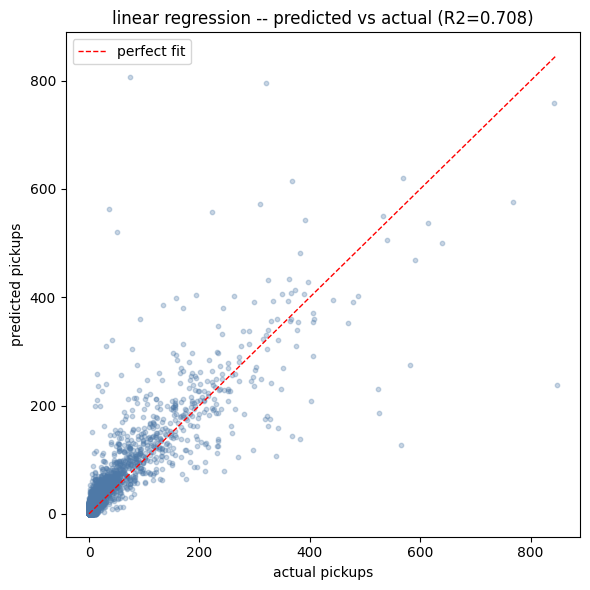

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_pred_test, alpha=0.3, s=10, color="#4e79a7")
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([0, max_val], [0, max_val], "r--", lw=1, label="perfect fit")
ax.set_xlabel("actual pickups")
ax.set_ylabel("predicted pickups")
ax.set_title(f"linear regression -- predicted vs actual (R2={lr_metrics['r2']:.3f})")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## saving results

In [5]:
results = {"Linear Regression": lr_metrics}

with open(RESULTS_DIR / "baseline_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved to results/baseline_metrics.json")
print(json.dumps(results, indent=2))

Saved to results/baseline_metrics.json
{
  "Linear Regression": {
    "mae": 11.1769,
    "rmse": 33.0073,
    "r2": 0.7083
  }
}
